## 1.1 Gaussian Noise

In [4]:
import numpy as np
import cv2
import matplotlib.pyplot as plt

In [5]:
def add_gaussian_noise(image, mean=0, std=1):
    """
    Adds Gaussian noise to an image.
    Parameters:
    - image: Input image to which noise will be
    added.
    - mean: Mean of the Gaussian distribution.
    Default is 0.
    - std: Standard deviation of the Gaussian
    distribution. Default is 1.
    Returns:
    - noisy_image: Image with added Gaussian noise.
    """
    # Generate Gaussian noise based on the shape of the image
    gaussian_noise = np.random.normal(mean, std, image.shape)
    # Add the noise to the original image and clip the result to stay within valid range
    noisy_image = image + gaussian_noise
    noisy_image = np.clip(noisy_image, 0, 255)
    return noisy_image

## 1.2. Rayleigh Noise

In [ ]:
def add_rayleigh_noise(image, scale=1):
  """
  Adds Rayleigh noise to an image.
  Parameters:
  - image: Input image to which noise will be
  added.
  - scale: Scale parameter for the Rayleigh
  distribution.
  Returns:
  - noisy_image: Image with added Rayleigh noise.
  """
  # Generate Rayleigh noise based on the shape of the image
  rayleigh_noise = np.random.rayleigh(scale, image.shape)
  # Add the noise to the original image and clip the result to stay within valid range
  noisy_image = image + rayleigh_noise
  noisy_image = np.clip(noisy_image, 0, 255)
  return noisy_image

## 1.3. Exponential Noise

In [6]:
def add_exponential_noise(image, scale=1):
  """
  Adds Exponential noise to an image.
  Parameters:
  - image: Input image to which noise will be
  added.
  - scale: Scale parameter for the Exponential
  distribution.
  Returns:
  - noisy_image: Image with added Exponential
  noise.
  """
  # Generate Exponential noise based on the shape of the image
  exponential_noise = np.random.exponential(scale, image.shape)
  # Add the noise to the original image and clip the result to stay within valid range
  noisy_image = image + exponential_noise
  noisy_image = np.clip(noisy_image, 0, 255)
  return noisy_image

## 1.4. Salt & Pepper Noise

In [10]:
def add_salt_pepper_noise(image, salt_prob=0.05, pepper_prob=0.05):
  """
  Adds Salt & Pepper noise to an image.
  Parameters:
  - image: Input image to which noise will be
  added.
  - salt_prob: Probability of adding salt (white)
  noise.
  - pepper_prob: Probability of adding pepper
  (black) noise.
  Returns:
  - noisy_image: Image with added Salt & Pepper
  noise.
  """
  noisy_image = image.copy()
  # Salt noise (white pixels)
  num_salt = np.ceil(salt_prob * image.size)
  coords = [np.random.randint(0, i - 1, int(num_salt)) for i in image.shape]
  noisy_image[coords[0], coords[1]] = 255
  # Pepper noise (black pixels)
  num_pepper = np.ceil(pepper_prob * image.size)
  coords = [np.random.randint(0, i - 1, int(num_pepper)) for i in image.shape]
  noisy_image[coords[0], coords[1]] = 0
  return noisy_image

## 1.5. Uniform Noise

In [11]:
def add_uniform_noise(image, low=0, high=10):
  """
  Adds Uniform noise to an image.
  Parameters:
  - image: Input image to which noise will be
  added.
  - low: Lower bound of the uniform noise.
  - high: Upper bound of the uniform noise.
  Returns:
  - noisy_image: Image with added Uniform noise.
  """
  # Generate Uniform noise based on the shape of the image
  uniform_noise = np.random.uniform(low, high, image.shape)
  # Add the noise to the original image and clip the result to stay within valid range
  noisy_image = image + uniform_noise
  noisy_image = np.clip(noisy_image, 0, 255)
  return noisy_image

## 2. Adding Noise to the image

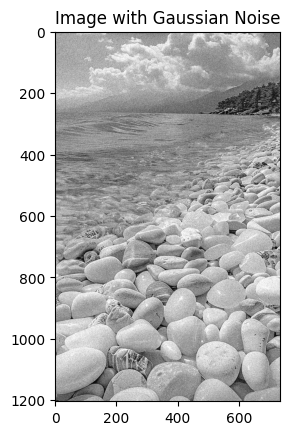

In [20]:
image = cv2.imread('/content/drive/MyDrive/Week 9/wallpaper.jpg', cv2.IMREAD_GRAYSCALE)
noisy_image = add_gaussian_noise(image, mean=0, std=20)
plt.imshow(noisy_image, cmap='gray')
plt.title("Image with Gaussian Noise")
plt.show()

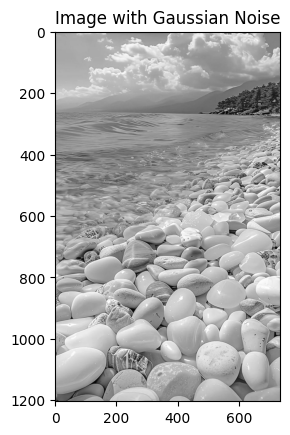

In [21]:
# Load an example image
image = cv2.imread('/content/drive/MyDrive/Week 9/wallpaper.jpg', cv2.IMREAD_GRAYSCALE)
# Add Rayleigh noise to the image
rayleigh_image = add_rayleigh_noise(image, scale=1)
# Display the rayleigh noisy image
plt.imshow(rayleigh_image, cmap='gray')
plt.title("Image with Gaussian Noise")
plt.show()

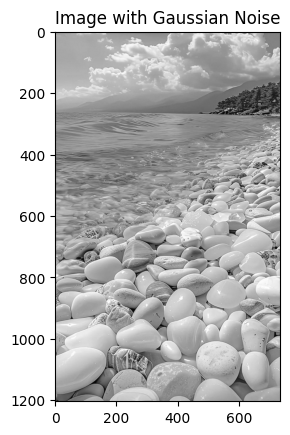

In [22]:
# Load an example image
image = cv2.imread('/content/drive/MyDrive/Week 9/wallpaper.jpg', cv2.IMREAD_GRAYSCALE)
# Add Rayleigh noise to the image
exponential_image = add_exponential_noise(image, scale=1)
# Display the rayleigh noisy image
plt.imshow(exponential_image, cmap='gray')
plt.title("Image with Gaussian Noise")
plt.show()

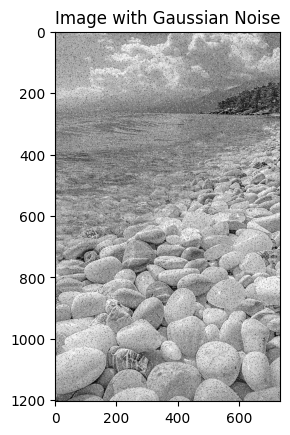

In [24]:
# Load an example image
image = cv2.imread('/content/drive/MyDrive/Week 9/wallpaper.jpg', cv2.IMREAD_GRAYSCALE)
# Add Rayleigh noise to the image
salt_pepper_noise = add_salt_pepper_noise(image, salt_prob=0.05, pepper_prob=0.05)
# Display the rayleigh noisy image
plt.imshow(salt_pepper_noise, cmap='gray')
plt.title("Image with Gaussian Noise")
plt.show()

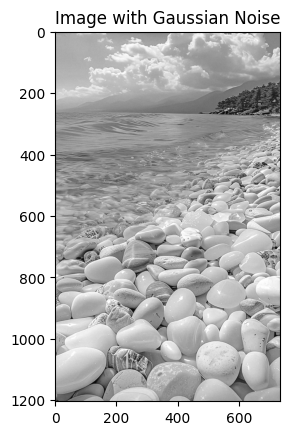

In [25]:
# Load an example image
image = cv2.imread('/content/drive/MyDrive/Week 9/wallpaper.jpg', cv2.IMREAD_GRAYSCALE)
# Add Rayleigh noise to the image
uniform_noise = add_uniform_noise(image, low=0, high=10)
# Display the rayleigh noisy image
plt.imshow(uniform_noise, cmap='gray')
plt.title("Image with Gaussian Noise")
plt.show()

# 2. Implementing filters

In [27]:
import copy
import numpy as np

def apply_box(image_input, box, filt_size):
    # Calculate the padding size based on the
    # filter size
    pad_size = int(np.floor(filt_size / 2))
    # Pad the input image symmetrically to handle
    # border pixels (mirror padding)
    image_padded = np.pad(image_input,
                          pad_width=((pad_size,
                                      pad_size), (pad_size, pad_size)),
                          mode='symmetric')
    # Create a deep copy of the input image to
    # store the filtered result
    image_box = copy.deepcopy(image_input)
    # Get the dimensions (number of rows and
    # columns) of the original input image
    row, column = image_input.shape
    # Loop over each pixel in the original image
    for i in range(row):
        for j in range(column):
            # Extract the current patch of the
            # padded image based on the filter size
            patch_curr = image_padded[i:i + filt_size, j:j + filt_size]
            # Multiply the current patch with the
            # box filter element-wise
            results_box = box * patch_curr
            # Assign the sum of the multiplied
            # patch as the new pixel value
            image_box[i, j] = np.sum(results_box)
    # Return the filtered image
    return image_box